In [3]:
import sys
import qiskit
import qiskit_ibm_runtime

print("Python executable:", sys.executable)
print("Qiskit module:", qiskit)

Python executable: C:\Users\rajesh zacharia\anaconda3\envs\qiskit_runtime\python.exe
Qiskit module: <module 'qiskit' from 'C:\\Users\\rajesh zacharia\\anaconda3\\envs\\qiskit_runtime\\Lib\\site-packages\\qiskit\\__init__.py'>


In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="YOUR_NEW_API_KEY_HERE",
    instance="YOUR_INSTANCE_CRN_HERE",
    channel="ibm_quantum_platform",
    set_as_default=True,
    overwrite=True        # <— add this
)

In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Remove any previously saved (bad) account
QiskitRuntimeService.delete_account()

True

In [8]:
QiskitRuntimeService.save_account(
    token="o-vywdNJr8UgKlhPUc_D4S8L6jOeD0cGN0i9DESbipus",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/21f91253eb8e426da037fd1c68faec83:97cc3263-9952-46fd-bc54-1105e6ddba56::",
    channel="ibm_quantum_platform",
    set_as_default=True,
    overwrite=True,  # make sure we overwrite anything old
)

In [4]:
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

service = QiskitRuntimeService()  # uses the new saved account

backend = service.least_busy(operational=True, min_num_qubits=3)
print("Using backend:", backend.name)
backend

Using backend: ibm_fez


<IBMBackend('ibm_fez')>

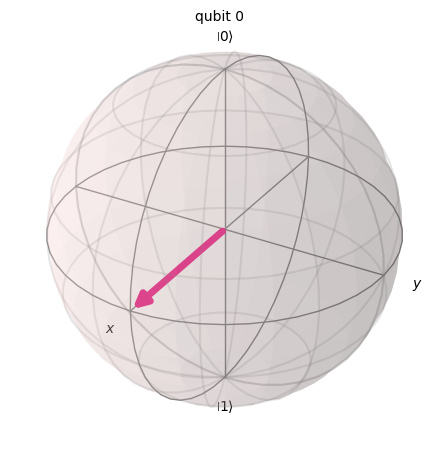

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Bloch sphere recap: put 1 qubit in |+> state
qc_bloch = QuantumCircuit(1)
qc_bloch.h(0)

state = Statevector.from_instruction(qc_bloch)
plot_bloch_multivector(state)

In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


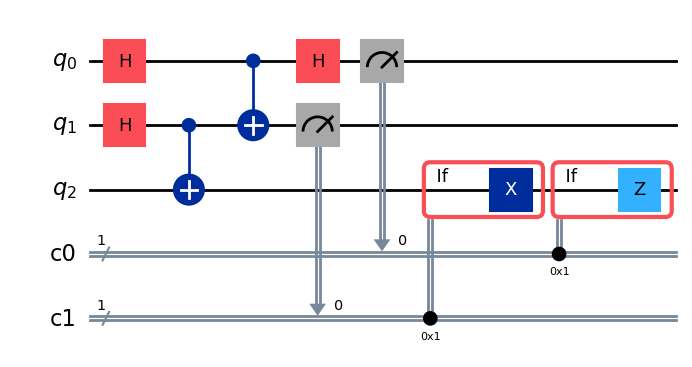

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# 3 qubits in one quantum register
q = QuantumRegister(3, "q")

# two 1-bit classical registers for Alice's measurement results
c0 = ClassicalRegister(1, "c0")
c1 = ClassicalRegister(1, "c1")

# build circuit from registers (no bare ints)
teleportation_circuit = QuantumCircuit(q, c0, c1, name="teleportation")

# Step 1: prepare state to teleport on q[0] (here |+>)
teleportation_circuit.h(q[0])

# Step 2: create Bell pair between q[1] and q[2]
teleportation_circuit.h(q[1])
teleportation_circuit.cx(q[1], q[2])

# Step 3: entangle q[0] with q[1]
teleportation_circuit.cx(q[0], q[1])
teleportation_circuit.h(q[0])

# Step 4: measure Alice's qubits into classical bits
teleportation_circuit.measure(q[0], c0[0])   # measurement of q0 -> c0
teleportation_circuit.measure(q[1], c1[0])   # measurement of q1 -> c1

# Step 5: conditional corrections on Bob's qubit q[2] (using if_test)

# X on q2 if c1 == 1
with teleportation_circuit.if_test((c1, 1)):
    teleportation_circuit.x(q[2])

# Z on q2 if c0 == 1
with teleportation_circuit.if_test((c0, 1)):
    teleportation_circuit.z(q[2])

teleportation_circuit.draw("mpl")

In [8]:
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


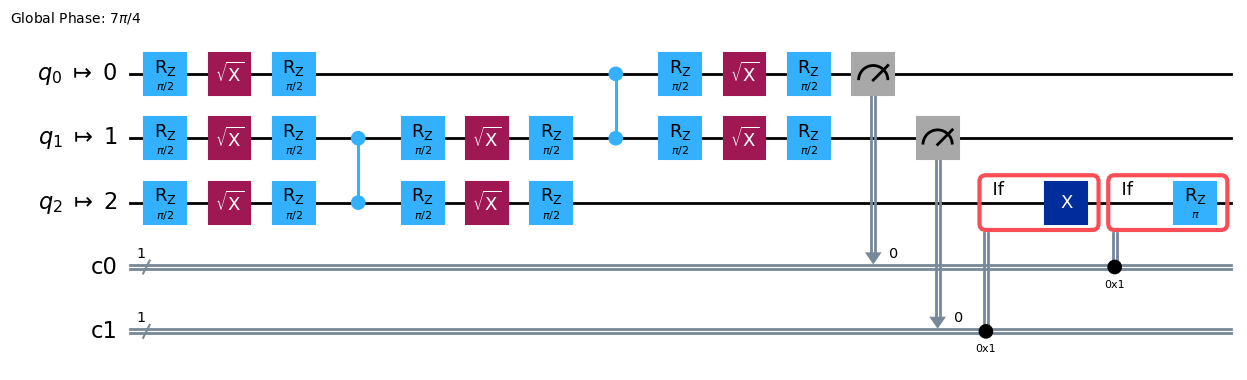

In [9]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(teleportation_circuit)
isa_circuit.draw("mpl")

Job ID: d4efibp2bisc73a1f6f0


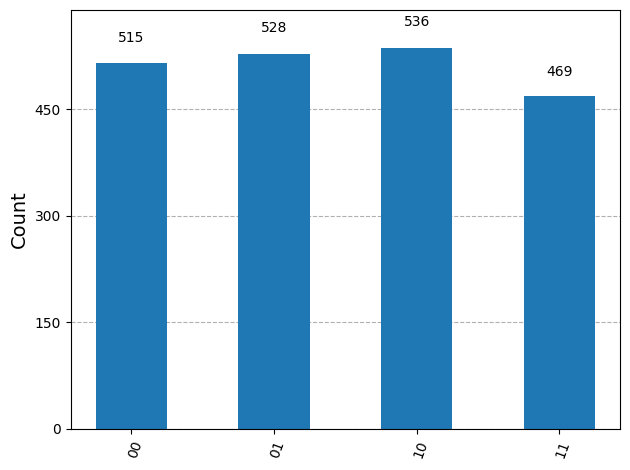

In [14]:
# Create a Sampler bound to your backend
sampler = Sampler(mode=backend)
sampler.options.default_shots = 2048  # number of repetitions

job = sampler.run([isa_circuit])
print("Job ID:", job.job_id())

pub_result = job.result()[0]
counts = pub_result.join_data().get_counts()

plot_histogram(counts)

Bitstring counts: {'01': 530, '11': 474, '00': 518, '10': 526}


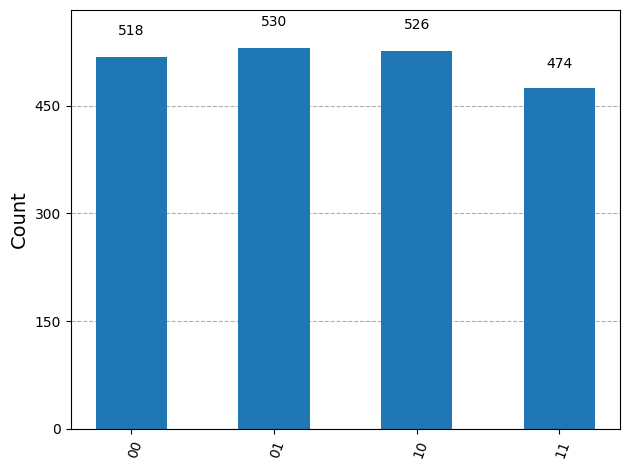

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram

service = QiskitRuntimeService()
job = service.job('d4ef2e4cdebc73ev1ma0')   # your job id
job_result = job.result()

pub_result = job_result[0]                  # first (and only) PUB
counts = pub_result.join_data().get_counts()

print("Bitstring counts:", counts)
plot_histogram(counts)